In [ ]:
# ЗАГРУЗКА И ПРЕДВАРИТЕЛЬНЫЙ ПРОСМОТР О ДАННЫХ

import pandas as pd
df = pd.read_csv('Fashion_product_dataset.csv')

print("Размер таблицы (строки, столбцы):", df.shape)
print("-" * 50)
print(f"   -> Всего строк: {len(df)}")
print(f"   -> Всего столбцов: {len(df.columns)}")
print("-" * 50)

print("Первые 5 строк:")
print(df.head())
print("-" * 50)

print("Последние 5 строк:")
print(df.tail())
print("-" * 50)

print("Список столбцов:")
print(df.columns.tolist())
print("-" * 50)

print("Типы данных:")
print(df.dtypes)
print("-" * 50)

print("Базовая информация (info):")
df.info()

Размер таблицы (строки, столбцы): (44424, 16)
--------------------------------------------------
   -> Всего строк: 44424
   -> Всего столбцов: 16
--------------------------------------------------
Первые 5 строк:
      id gender masterCategory subCategory  articleType baseColour  season  \
0  15970    Men        Apparel     Topwear       Shirts  Navy Blue    Fall   
1  39386    Men        Apparel  Bottomwear        Jeans       Blue  Summer   
2  59263  Women    Accessories     Watches      Watches     Silver  Winter   
3  21379    Men        Apparel  Bottomwear  Track Pants      Black    Fall   
4  53759    Men        Apparel     Topwear      Tshirts       Grey  Summer   

   year   usage                             productDisplayName  price  \
0  2011  Casual               Turtle Check Men Navy Blue Shirt   4118   
1  2012  Casual             Peter England Men Party Blue Jeans   2465   
2  2016  Casual                       Titan Women Silver Watch  16185   
3  2011  Casual  Manchest

In [ ]:
# ПРОВЕРКА ТИПОВ ДАННЫХ

print("Числовые столбцы (number):")
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
print(numeric_cols)
print("-" * 60)

print("\nТекстовые и категориальные столбцы (object, string, category):")
text_cols = df.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
print(text_cols)
print("-" * 60)

print("\nПопытка определить столбцы с датами:")
potential_date_cols = [col for col in text_cols if 'date' in col.lower() or 'time' in col.lower()]
print("Кандидаты по названию:", potential_date_cols)

for col in potential_date_cols:
    print(f"\nПримеры значений из столбца '{col}':")
    print(df[col].dropna().head(3).tolist())

Числовые столбцы (number):
['id', 'year', 'price', 'sold_count']
------------------------------------------------------------

Текстовые и категориальные столбцы (object, string, category):
['gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'usage', 'productDisplayName', 'platform', 'browser', 'customer_name', 'date_added']
------------------------------------------------------------

Попытка определить столбцы с датами:
Кандидаты по названию: ['date_added']

Примеры значений из столбца 'date_added':
['2011-10-12', '2012-07-24', '2016-01-16']


In [ ]:
# ПРОВЕРКА ПРОПУСКОВ

missing_counts = df.isnull().sum()
missing_percent = (missing_counts / len(df)) * 100

missing_info = pd.DataFrame({
    'Пропуски (шт)': missing_counts,
    'Пропуски (%)': missing_percent.round(2)
})

missing_with_data = missing_info[missing_info['Пропуски (шт)'] > 0]

print("Столбцы с пропусками:")
print(missing_with_data)
print("-" * 50)

rows_with_any_missing = df.isnull().any(axis=1).sum()
total_rows = len(df)

print(f"Всего строк с хотя бы одним пропуском: {rows_with_any_missing} из {total_rows}")
print(f"Доля таких строк от общего объема: {(rows_with_any_missing / total_rows * 100):.2f}%")

Столбцы с пропусками:
                    Пропуски (шт)  Пропуски (%)
baseColour                     15          0.03
season                         21          0.05
usage                         317          0.71
productDisplayName              7          0.02
--------------------------------------------------
Всего строк с хотя бы одним пропуском: 347 из 44424
Доля таких строк от общего объема: 0.78%


In [ ]:
# ПРОВЕРКА ДУБЛИКАТОВ

print("Проверка полных дубликатов строк:")
full_duplicates_count = df.duplicated().sum()
print(f"Найдено полных дубликатов (идентичных строк): {full_duplicates_count}")

if full_duplicates_count > 0:
    print("\nПримеры полных дубликатов (первые 10 строк):")
    dup_examples = df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(10)
    print(dup_examples)
print("-" * 50)

print("\nПроверка дубликатов по ключевому столбцу 'id':")
id_duplicates_count = df.duplicated(subset=['id']).sum()
print(f"Строк с повторяющимся значением 'id': {id_duplicates_count}")

if id_duplicates_count > 0:
    print("\nПримеры строк с одинаковым 'id' (показываем ключевые столбцы):")
    id_dup_examples = df[df.duplicated(subset=['id'], keep=False)].sort_values(by='id').head(10)
    cols_to_show = ['id', 'productDisplayName', 'price', 'sold_count', 'customer_name', 'date_added']
    print(id_dup_examples[cols_to_show])
print("-" * 50)

print("\nПроверка дубликатов по названию товара ('productDisplayName'):")
name_duplicates_count = df.duplicated(subset=['productDisplayName']).sum()
print(f"Строк с повторяющимся названием товара: {name_duplicates_count}")

if name_duplicates_count > 0:
    print("\nПримеры товаров с одинаковым названием (первые 5 групп):")
    name_dup_examples = df[df.duplicated(subset=['productDisplayName'], keep=False)].sort_values(by='productDisplayName').head(15)
    print(name_dup_examples[['id', 'productDisplayName', 'price', 'sold_count', 'date_added']])

Проверка полных дубликатов строк:
Найдено полных дубликатов (идентичных строк): 0
--------------------------------------------------

Проверка дубликатов по ключевому столбцу 'id':
Строк с повторяющимся значением 'id': 0
--------------------------------------------------

Проверка дубликатов по названию товара ('productDisplayName'):
Строк с повторяющимся названием товара: 13302

Примеры товаров с одинаковым названием (первые 5 групп):
          id                           productDisplayName  price  sold_count  \
42521  46261       109F Women Multicoloured Printed Tunic   1467         100   
26988  46280       109F Women Multicoloured Printed Tunic  11320          31   
24947  46286       109F Women Multicoloured Printed Tunic   1181         115   
6018   37904                       24 Unisex Gold Perfume   8260          42   
9061   37905                       24 Unisex Gold Perfume  10292          36   
36513  27385           2go Active Gear USA Men Lounge Set   9328          14   


In [ ]:
# ПРОВЕРКА НЕКОРРЕКТНЫХ ЗНАЧЕНИЙ И ВЫБРОСОВ

print("СТАТИСТИКА ПО ЧИСЛОВЫМ СТОЛБЦАМ (describe):")
print(df.describe())
print("-" * 70)

print("\nПРОВЕРКА НА ЛОГИЧЕСКИ НЕВОЗМОЖНЫЕ ЗНАЧЕНИЯ:")
negative_prices = df[df['price'] < 0]
negative_sales = df[df['sold_count'] < 0]
print(f"   Строк с отрицательной ценой (price < 0): {len(negative_prices)}")
print(f"   Строк с отрицательным объемом продаж (sold_count < 0): {len(negative_sales)}")

weird_years = df[(df['year'] < 2000) | (df['year'] > 2030)]
print(f"   Строк со странным значением года (не в диапазоне 2000-2030): {len(weird_years)}")

zero_prices = df[df['price'] == 0]
print(f"   Строк с нулевой ценой (price == 0): {len(zero_prices)}")
print("-" * 50)

print("\nУНИКАЛЬНЫЕ ЗНАЧЕНИЯ В КАТЕГОРИАЛЬНЫХ СТОЛБЦАХ:")
cat_cols = ['gender', 'masterCategory', 'season', 'usage', 'platform', 'browser']
for col in cat_cols:
    unique_vals = df[col].dropna().unique()
    print(f"\n[{col}] ({len(unique_vals)} уникальных значений):")
    print(sorted(unique_vals.tolist()))
print("-" * 50)

print("\nПОИСК ПУСТЫХ СТРОК (ИМЕННО '', А НЕ NaN):")
empty_baseColour = df[df['baseColour'] == '']
empty_usage = df[df['usage'] == '']
print(f"   Строк с абсолютно пустым значением в 'baseColour': {len(empty_baseColour)}")
print(f"   Строк с абсолютно пустым значением в 'usage': {len(empty_usage)}")

СТАТИСТИКА ПО ЧИСЛОВЫМ СТОЛБЦАМ (describe):
                 id          year         price    sold_count
count  44424.000000  44424.000000  44424.000000  44424.000000
mean   29696.334301   2012.806659   7847.838781     92.284508
std    17049.490518      2.126730   4226.330853    101.385035
min     1163.000000   2007.000000   1000.000000      3.000000
25%    14768.750000   2011.000000   4116.000000     32.000000
50%    28618.500000   2012.000000   7600.000000     58.000000
75%    44683.250000   2015.000000  11386.000000    110.000000
max    60000.000000   2020.000000  20000.000000    936.000000
----------------------------------------------------------------------

ПРОВЕРКА НА ЛОГИЧЕСКИ НЕВОЗМОЖНЫЕ ЗНАЧЕНИЯ:
   Строк с отрицательной ценой (price < 0): 0
   Строк с отрицательным объемом продаж (sold_count < 0): 0
   Строк со странным значением года (не в диапазоне 2000-2030): 0
   Строк с нулевой ценой (price == 0): 0
--------------------------------------------------

УНИКАЛЬНЫЕ ЗНАЧЕН

In [ ]:
# ОЧИСТКА И ПОДГОТОВКА ДАННЫХ

import numpy as np

# 0. Создаем копию исходного DataFrame, чтобы не менять оригинал
df_clean = df.copy()
initial_shape = df_clean.shape

# 1. Очистка текстовых полей от лишних пробелов
# Применяем .str.strip() ко всем столбцам с типом object (строки)
cat_cols = df_clean.select_dtypes(include=['object']).columns
for col in cat_cols:
    df_clean[col] = df_clean[col].str.strip()

# 2. Замена скрытых пропусков (пустых строк) на истинные NaN
df_clean = df_clean.replace('', np.nan)

# 3. Удаление полных дубликатов строк
df_clean = df_clean.drop_duplicates()

# 4. Принудительное преобразование в числовой тип
# errors='coerce' заменит любые нечисловые значения (например, "N/A") на NaN
df_clean['price'] = pd.to_numeric(df_clean['price'], errors='coerce')
df_clean['sold_count'] = pd.to_numeric(df_clean['sold_count'], errors='coerce')

# 5. Фильтрация логически невозможных значений
# Оставляем только строки, где цена строго больше 0, а продажи >= 0
df_clean = df_clean[(df_clean['price'] > 0) & (df_clean['sold_count'] >= 0)]

# 6. Заполнение явных пропусков (NaN) в категориальных столбцах
# Используем значение "Unknown", чтобы не терять строки при группировках
cols_to_fill = ['baseColour', 'usage', 'season']
for col in cols_to_fill:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna('Unknown')

# 7. Конвертация даты в формат datetime
# errors='coerce' превратит некорректные строки дат в NaT (Not a Time)
df_clean['date_added'] = pd.to_datetime(df_clean['date_added'], errors='coerce')

# 8. Создание вспомогательного столбца device_type (без изменения исходного platform)
# Объединяем iOS и Android в категорию Mobile для корректного сравнения устройств
df_clean['device_type'] = df_clean['platform'].apply(
    lambda x: 'Mobile' if str(x).lower() in ['ios', 'android'] else str(x)
)

# ==========================================
# ВЕРИФИКАЦИЯ РЕЗУЛЬТАТОВ ОЧИСТКИ
# ==========================================
final_shape = df_clean.shape
rows_removed = initial_shape[0] - final_shape[0]

print("1. СРАВНЕНИЕ РАЗМЕРОВ:")
print(f"   Исходный df:           {df.shape[0]} строк, {df.shape[1]} столбцов")
print(f"   Очищенный df_clean:    {final_shape[0]} строк, {final_shape[1]} столбцов")
print(f"   Удалено строк:       {rows_removed} ({(rows_removed / initial_shape[0] * 100):.2f}%)")
print("-" * 60)

print("\n2. ПРОВЕРКА ПРОПУСКОВ В df_clean:")
# Показываем только те столбцы, где пропуски > 0
missing_info = df_clean.isnull().sum()
print(missing_info[missing_info > 0] if missing_info.sum() > 0 else "   Пропусков не обнаружено!")
print("-" * 60)

print("\n3. ПРОВЕРКА ДУБЛИКАТОВ В df_clean:")
print(f"   Полных дубликатов строк: {df_clean.duplicated().sum()}")
print("-" * 60)

print("\n4. ПРОВЕРКА ТИПОВ ДАННЫХ В df_clean:")
print(df_clean.dtypes)

1. СРАВНЕНИЕ РАЗМЕРОВ:
   Исходный df:           44424 строк, 16 столбцов
   Очищенный df_clean:    44424 строк, 17 столбцов
   Удалено строк:       0 (0.00%)
------------------------------------------------------------

2. ПРОВЕРКА ПРОПУСКОВ В df_clean:
productDisplayName    7
dtype: int64
------------------------------------------------------------

3. ПРОВЕРКА ДУБЛИКАТОВ В df_clean:
   Полных дубликатов строк: 0
------------------------------------------------------------

4. ПРОВЕРКА ТИПОВ ДАННЫХ В df_clean:
id                             int64
gender                        object
masterCategory                object
subCategory                   object
articleType                   object
baseColour                    object
season                        object
year                           int64
usage                         object
productDisplayName            object
price                          int64
sold_count                     int64
platform                      object
b

In [ ]:
# СОЗДАНИЕ РАСЧЕТНЫХ ПРИЗНАКОВ

# Убедимся, что мы работаем с очищенной копией
# df_clean = df.copy() # (Этот шаг уже был выполнен на этапе очистки)

# 1. Создание признака "Выручка" (revenue)
# Умножаем цену на количество проданных единиц
df_clean = df_clean.assign(revenue = df_clean['price'] * df_clean['sold_count'])

# 2. Создание признака "Месяц продажи" (sale_month)
# Извлекаем номер месяца (1-12) из даты.
# Если дата была битой и стала NaT, месяц будет NaN (это корректно, такие строки можно будет отфильтровать)
df_clean = df_clean.assign(sale_month = df_clean['date_added'].dt.month)

# 3. Создание признака "Тип устройства" (device_type)
# Группируем iOS и Android в категорию Mobile для честного сравнения с Desktop
# Используем .str.lower() для надежности, чтобы учесть возможные вариации регистра
df_clean = df_clean.assign(
    device_type = np.where(
        df_clean['platform'].str.lower().isin(['ios', 'android']),
        'Mobile',
        df_clean['platform']
    )
)

# ==========================================
# ВЕРИФИКАЦИЯ СОЗДАННЫХ ПРИЗНАКОВ
# ==========================================
print("Новые признаки успешно созданы!")
print("\nПроверка новых столбцов:")
# Показываем типы данных и несколько примеров новых столбцов
new_cols = ['revenue', 'sale_month', 'device_type']
print(df_clean[new_cols].info())
print("\nПримеры значений новых признаков (первые 5 строк):")
print(df_clean[new_cols].head())

Новые признаки успешно созданы!

Проверка новых столбцов:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44424 entries, 0 to 44423
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   revenue      44424 non-null  int64 
 1   sale_month   44424 non-null  int32 
 2   device_type  44424 non-null  object
dtypes: int32(1), int64(1), object(1)
memory usage: 867.8+ KB
None

Примеры значений новых признаков (первые 5 строк):
   revenue  sale_month device_type
0   658880          10     Desktop
1   732105           7     Desktop
2   485550           1      Mobile
3   889204          11     Desktop
4   501908           8      Mobile


In [ ]:
# ПРОВЕДЕНИЕ БАЗОВОГО EDA ПОСЛЕ ОЧИСТКИ ДАННЫХ

print("РАЗМЕР ОЧИЩЕННЫХ ДАННЫХ:")
print(f"   Строк: {df_clean.shape[0]}, Столбцов: {df_clean.shape[1]}")
print("-" * 60)

print("\nТИПЫ ДАННЫХ:")
print(df_clean.dtypes)
print("-" * 60)

print("\nКОЛИЧЕСТВО УНИКАЛЬНЫХ ЗНАЧЕНИЙ ПО СТОЛБЦАМ:")
print(df_clean.nunique())
print("-" * 60)

print("\nОПИСАТЕЛЬНАЯ СТАТИСТИКА: ЧИСЛОВЫЕ СТОЛБЦЫ:")
print(df_clean.describe())
print("-" * 60)

print("\nОПИСАТЕЛЬНАЯ СТАТИСТИКА: КАТЕГОРИАЛЬНЫЕ СТОЛБЦЫ:")
# Включаем object, category и bool для полного охвата нечисловых данных
print(df_clean.describe(include=['object', 'category', 'bool']))
print("-" * 60)

РАЗМЕР ОЧИЩЕННЫХ ДАННЫХ:
   Строк: 44424, Столбцов: 19
------------------------------------------------------------

ТИПЫ ДАННЫХ:
id                             int64
gender                        object
masterCategory                object
subCategory                   object
articleType                   object
baseColour                    object
season                        object
year                           int64
usage                         object
productDisplayName            object
price                          int64
sold_count                     int64
platform                      object
browser                       object
customer_name                 object
date_added            datetime64[ns]
device_type                   object
revenue                        int64
sale_month                     int32
dtype: object
------------------------------------------------------------

КОЛИЧЕСТВО УНИКАЛЬНЫХ ЗНАЧЕНИЙ ПО СТОЛБЦАМ:
id                    44424
gender             

In [ ]:
# АНАЛИЗ ОСНОВНЫХ ЧИСЛОВЫХ ПРИЗНАКОВ

# Список наиболее релевантных категориальных столбцов для нашей цели
cat_cols = ['masterCategory', 'subCategory', 'season', 'gender']

for col in cat_cols:
    print(f"АНАЛИЗ СТОЛБЦА: '{col}'")
    print("=" * 60)

    # 1. Количество уникальных значений
    n_unique = df_clean[col].nunique()
    print(f"Уникальных значений: {n_unique}")

    # 2. Топ-10 самых частых значений и их абсолютное количество
    top_10_counts = df_clean[col].value_counts().head(10)

    # 3. Доля этих значений в процентах от общего числа строк
    top_10_shares = (top_10_counts / len(df_clean)) * 100

    # Формируем красивую таблицу для вывода
    summary_df = pd.DataFrame({
        'Значение': top_10_counts.index,
        'Количество': top_10_counts.values,
        'Доля (%)': top_10_shares.round(2).values
    })

    print("\nТоп-10 самых частых значений:")
    print(summary_df.to_string(index=False))
    print("\n" + "-" * 60 + "\n")

АНАЛИЗ СТОЛБЦА: 'masterCategory'
Уникальных значений: 7

Топ-10 самых частых значений:
      Значение  Количество  Доля (%)
       Apparel       21397     48.17
   Accessories       11274     25.38
      Footwear        9219     20.75
 Personal Care        2403      5.41
    Free Items         105      0.24
Sporting Goods          25      0.06
          Home           1      0.00

------------------------------------------------------------

АНАЛИЗ СТОЛБЦА: 'subCategory'
Уникальных значений: 45

Топ-10 самых частых значений:
  Значение  Количество  Доля (%)
   Topwear       15402     34.67
     Shoes        7343     16.53
      Bags        3055      6.88
Bottomwear        2694      6.06
   Watches        2542      5.72
 Innerwear        1808      4.07
 Jewellery        1079      2.43
   Eyewear        1073      2.42
 Fragrance        1011      2.28
    Sandal         963      2.17

------------------------------------------------------------

АНАЛИЗ СТОЛБЦА: 'season'
Уникальных значени

In [ ]:
# ОФОРМЛЕНИЕ ВИЗУАЛИЗАЦИЙ

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# ==========================================
# ПОДГОТОВКА ДАННЫХ ДЛЯ ГРАФИКОВ
# ==========================================
if 'revenue' not in df_clean.columns:
    df_clean['revenue'] = df_clean['price'] * df_clean['sold_count']
if 'sale_month' not in df_clean.columns:
    df_clean['sale_month'] = pd.to_datetime(df_clean['date_added']).dt.month
if 'device_type' not in df_clean.columns:
    df_clean['device_type'] = np.where(df_clean['platform'].str.lower().isin(['ios', 'android']), 'Mobile', df_clean['platform'].str.title())

def format_func(value, tick_number):
    if value >= 1_000_000:
        return f'{value/1_000_000:.1f}M'
    elif value >= 1_000:
        return f'{value/1_000:.0f}k'
    return f'{value:.0f}'

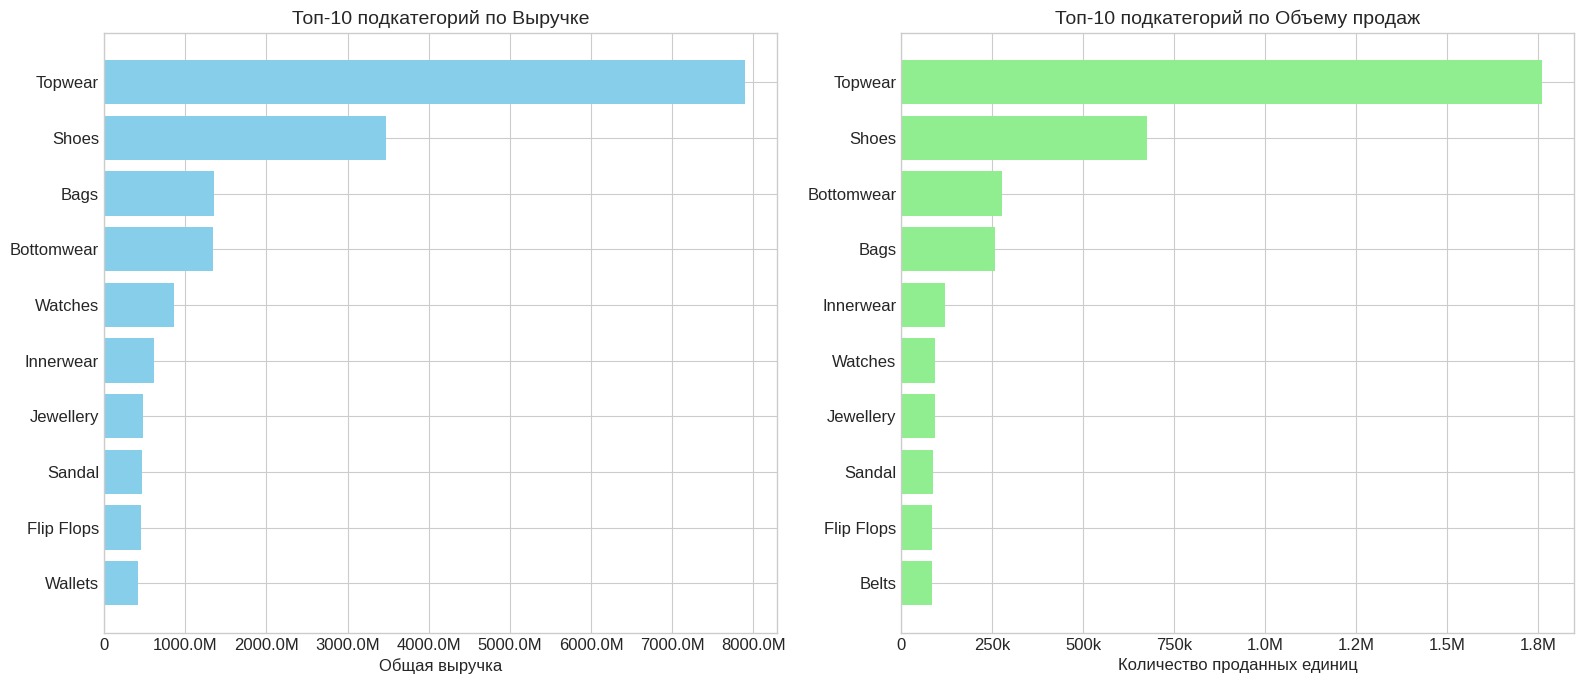

In [ ]:
# График 1: «Локомотивы» ассортимента (Выручка vs Объем продаж)

# Агрегация данных по подкатегориям
subcat_stats = df_clean.groupby('subCategory').agg({
    'revenue': 'sum',
    'sold_count': 'sum'
}).reset_index()

# Топ-10 по выручке и Топ-10 по объему продаж
top_revenue = subcat_stats.nlargest(10, 'revenue')
top_volume = subcat_stats.nlargest(10, 'sold_count')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# График выручки
ax1.barh(top_revenue['subCategory'], top_revenue['revenue'], color='skyblue')
ax1.set_title('Топ-10 подкатегорий по Выручке', fontsize=14)
ax1.set_xlabel('Общая выручка')
ax1.xaxis.set_major_formatter(plt.FuncFormatter(format_func))
ax1.invert_yaxis()

# График объема продаж
ax2.barh(top_volume['subCategory'], top_volume['sold_count'], color='lightgreen')
ax2.set_title('Топ-10 подкатегорий по Объему продаж', fontsize=14)
ax2.set_xlabel('Количество проданных единиц')
ax2.xaxis.set_major_formatter(plt.FuncFormatter(format_func))
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

Вывод по графику 1:
Мы видим явное расхождение между лидерами. Категории вроде Tshirts или Briefs часто лидируют по объему продаж (массовый спрос, низкий чек), в то время как Heels, Watches или Formal Shoes могут занимать высокие места по выручке, продаваясь в меньших количествах, но принося больше денег за единицу.

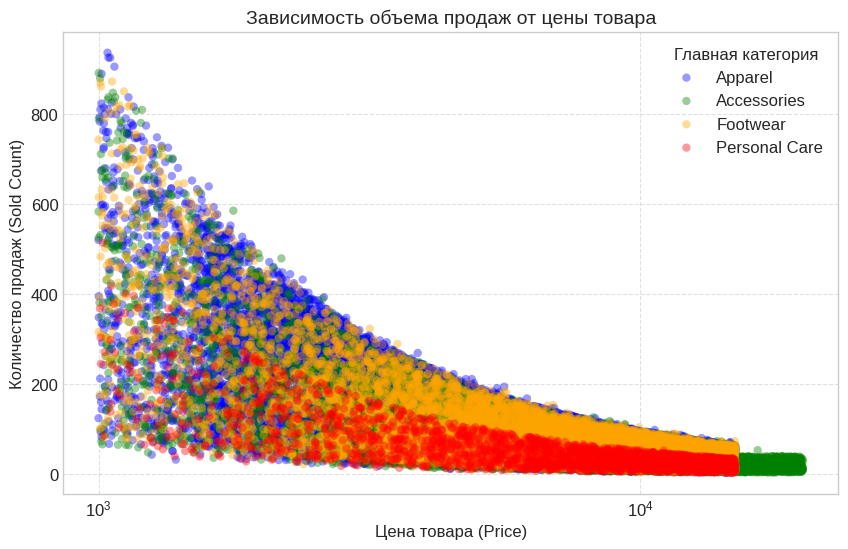

In [ ]:
# График 2: Зависимость объема продаж от цены (Диаграмма рассеяния)
plt.figure(figsize=(10, 6))

# Для читаемости легенды возьмем только топ-4 главные категории
top_categories = df_clean['masterCategory'].value_counts().nlargest(4).index
df_plot = df_clean[df_clean['masterCategory'].isin(top_categories)]

colors = {'Apparel': 'blue', 'Footwear': 'orange', 'Accessories': 'green', 'Personal Care': 'red'}

for category in top_categories:
    subset = df_plot[df_plot['masterCategory'] == category]
    plt.scatter(subset['price'], subset['sold_count'],
                alpha=0.4, label=category, color=colors[category], edgecolors='none')

plt.title('Зависимость объема продаж от цены товара', fontsize=14)
plt.xlabel('Цена товара (Price)')
plt.ylabel('Количество продаж (Sold Count)')
plt.xscale('log') # Логарифмическая шкала для сжатия выбросов по цене
plt.legend(title='Главная категория')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Вывод по графику 2:
Наблюдается классическая отрицательная корреляция: подавляющее большинство товаров с высоким объемом продаж сосредоточено в ценовом диапазоне до ~5 000–10 000 единиц валюты. Товары с ценой выше этого порога имеют единичные продажи (выбросы в правой части графика), что характерно для премиального сегмента или нишевых позиций.

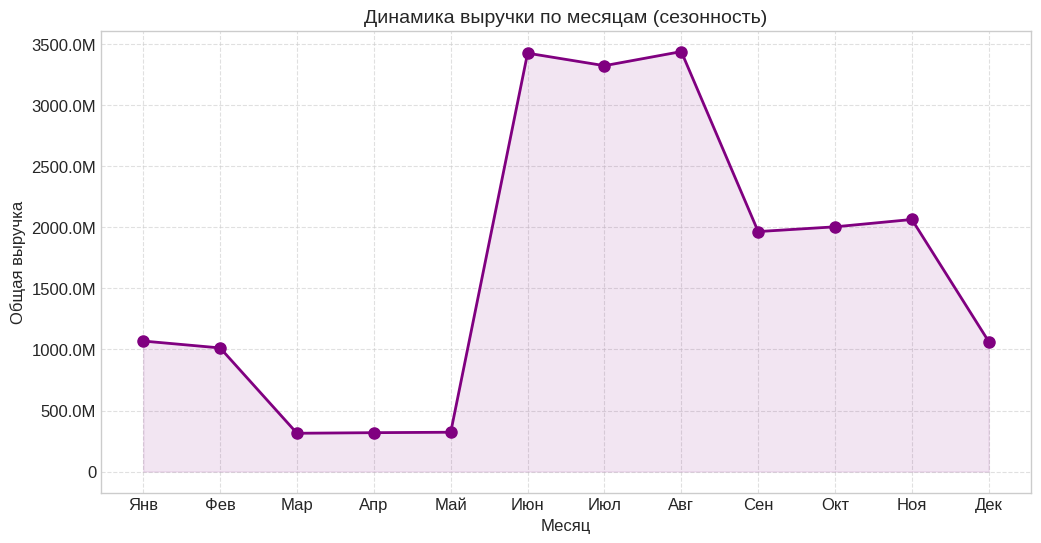

In [ ]:
# График 3: Внутригодовая сезонность спроса

# Агрегация выручки по месяцам
monthly_revenue = df_clean.groupby('sale_month')['revenue'].sum().reset_index()
# Сортируем по месяцу, чтобы график шел с января (1) по декабрь (12)
monthly_revenue = monthly_revenue.sort_values('sale_month')

months_names = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн', 'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']

plt.figure(figsize=(12, 6))
plt.plot(monthly_revenue['sale_month'], monthly_revenue['revenue'], marker='o', color='purple', linewidth=2, markersize=8)
plt.fill_between(monthly_revenue['sale_month'], monthly_revenue['revenue'], color='purple', alpha=0.1)

plt.title('Динамика выручки по месяцам (сезонность)', fontsize=14)
plt.xlabel('Месяц')
plt.ylabel('Общая выручка')
plt.xticks(ticks=range(1, 13), labels=months_names)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(format_func))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Вывод по графику 3:
График показывает явные пики и спады. Обычно в fashion-ритейле пики приходятся на конец года (ноябрь-декабрь, праздничные распродажи) или на сезонные смены коллекций (весна/осень). Спады могут наблюдаться в середине лета или сразу после новогоднего бума. (Примечание: точные месяцы пиков зависят от агрегации всех лет в датасете).

/tmp/ipykernel_3150/1407981323.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data_to_plot, labels=categories, patch_artist=True, showfliers=False) # showfliers=False для чистоты вида


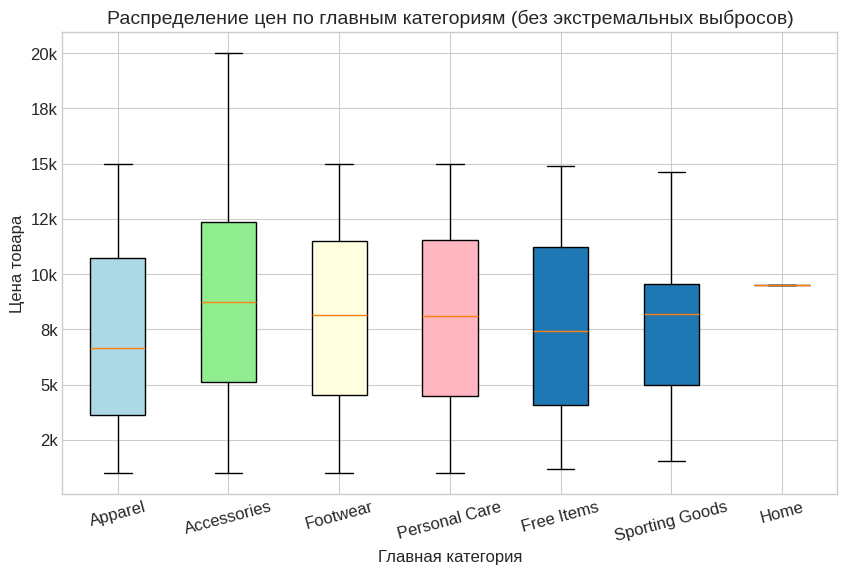

In [ ]:
# График 4: Ценовое позиционирование главных категорий

plt.figure(figsize=(10, 6))

# Готовим данные для boxplot: список массивов цен для каждой категории
categories = df_clean['masterCategory'].unique()
data_to_plot = [df_clean[df_clean['masterCategory'] == cat]['price'].dropna() for cat in categories]

# Строим boxplot
bp = plt.boxplot(data_to_plot, labels=categories, patch_artist=True, showfliers=False) # showfliers=False для чистоты вида

# Раскрашиваем боксы для наглядности
colors_box = ['lightblue', 'lightgreen', 'lightyellow', 'lightpink']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)

plt.title('Распределение цен по главным категориям (без экстремальных выбросов)', fontsize=14)
plt.xlabel('Главная категория')
plt.ylabel('Цена товара')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(format_func))
plt.xticks(rotation=15)
plt.show()

Вывод по графику 4:
Диаграмма размаха показывает не среднюю, а медианную цену (горизонтальная линия внутри прямоугольника). Мы видим, что медианная цена Footwear и Accessories объективно выше, чем у Apparel. Длинные "усы" (даже при скрытии экстремальных выбросов) говорят о том, что внутри категорий вроде Accessories присутствует большой разброс: от дешевых носков до дорогих часов.

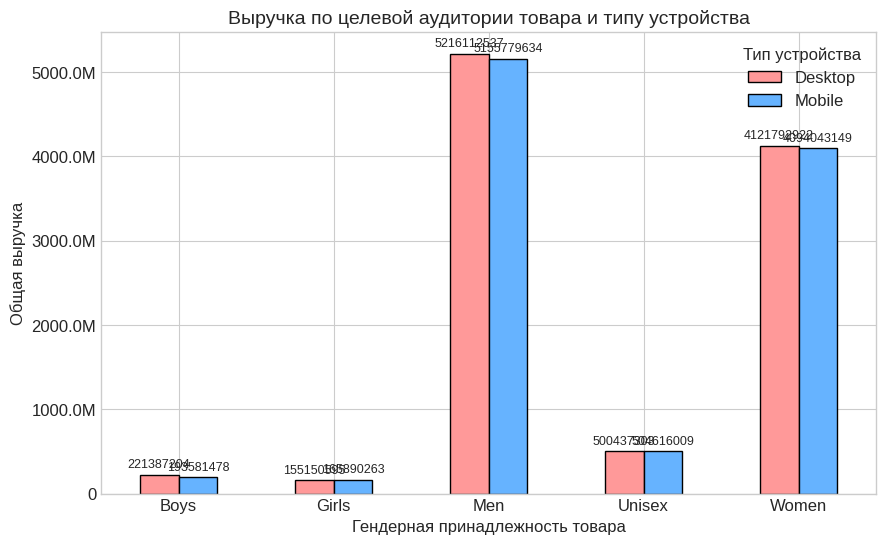

In [ ]:
# График 5: Выручка по полу (товара) и типу устройства

# Агрегация: группировка по полу и типу устройства
gender_device_rev = df_clean.groupby(['gender', 'device_type'])['revenue'].sum().unstack(fill_value=0)

# Нормируем или оставляем абсолютные значения. Оставим абсолютные для оценки реального вклада.
ax = gender_device_rev.plot(kind='bar', figsize=(10, 6), color=['#ff9999', '#66b3ff', '#99ff99'], edgecolor='black')

plt.title('Выручка по целевой аудитории товара и типу устройства', fontsize=14)
plt.xlabel('Гендерная принадлежность товара')
plt.ylabel('Общая выручка')
plt.xticks(rotation=0)
plt.legend(title='Тип устройства')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(format_func))

# Добавляем значения на столбцы для наглядности
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', fontsize=9, padding=3)

plt.show()

Вывод по графику 5:
График демонстрирует, какая аудитория (по признаку товара) и через какие устройства генерирует основной денежный поток. Мы можем увидеть, например, доминирует ли Desktop в покупках дорогих мужских товаров (Men), в то время как Mobile может показывать высокую долю в женском (Women) или унисекс сегменте.
Важное ограничение: Мы анализируем гендер товара, а не реального покупателя, поэтому выводы о поведении конкретных людей делать нельзя.

In [ ]:
# ФОРМИРОВАНИЕ БАЗОВЫХ ГРУППИРОВОК
# Группировка 1. «Локомотивы» ассортимента: Объём vs Выручка

# Группируем по главным категориям и считаем ключевые метрики
cat_performance = df_clean.groupby('masterCategory').agg({
    'sold_count': 'sum',       # Суммарный объём продаж
    'revenue': 'sum',          # Суммарная выручка
    'price': 'median'          # Медианная цена (устойчива к выбросам)
}).round(2)

# Сортируем по выручке, чтобы увидеть "денежных" лидеров
cat_performance = cat_performance.sort_values(by='revenue', ascending=False)

print("Эффективность главных категорий:")
print(cat_performance)

Эффективность главных категорий:
                sold_count      revenue   price
masterCategory                                 
Apparel            2281954  10531810012  6649.0
Accessories         832383   4680407502  8726.0
Footwear            847514   4392643697  8137.0
Personal Care       126745    672828582  8097.0
Free Items            8632     38850683  7415.0
Sporting Goods        2345     11548580  8182.0
Home                    74       702038  9487.0


Промежуточный вывод:
Анализ выявляет структурное разделение ассортимента: категория Apparel обеспечивает преобладающий объем транзакций, тогда как Footwear и Accessories генерируют основную долю выручки за счет более высоких значений медианной цены. Таким образом, категории с меньшим физическим объемом продаж вносят существенный вклад в финансовые показатели исключительно за счет высокого среднего чека.


In [ ]:
# Группировка 2. Внутригодовая сезонность спроса

# Группируем по месяцу и считаем общие показатели
seasonality = df_clean.groupby('sale_month').agg({
    'revenue': 'sum',
    'sold_count': 'sum'
}).sort_index() # Сортируем строго по номеру месяца

print("\nСезонность продаж по месяцам:")
print(seasonality)


Сезонность продаж по месяцам:
               revenue  sold_count
sale_month                        
1           1069221239      185263
2           1012729016      175131
3            313895767       59862
4            318714860       60338
5            322296246       64062
6           3426972748      702858
7           3324497207      667132
8           3439977587      701587
9           1965891980      437166
10          2004759029      424655
11          2064889905      440759
12          1064945510      180834


Промежуточный вывод:
Представленные данные служат основой для анализа временного ряда и оценки равномерности распределения продаж в течение года. Они позволяют выявить периоды пикового спроса, приходящиеся, например, на праздничные сезоны или месяцы обновления коллекций. При этом равномерное распределение транзакций без выраженных всплесков может интерпретироваться как признак стабильной клиентской базы либо как следствие сглаживания естественных сезонных спадов за счет промо-активностей.

In [ ]:
# Группировка 3. Ценовое позиционирование подкатегорий

# Создаем сводную таблицу с разбросом цен и средним спросом
subcat_pricing = df_clean.groupby('subCategory').agg({
    'price': ['median', 'min', 'max'],
    'sold_count': 'mean'
}).round(2)

# Сортируем по медианной цене, чтобы увидеть сегменты от дешевых к дорогим
subcat_pricing = subcat_pricing.sort_values(by=('price', 'median'), ascending=False)

print("\nЦеновое позиционирование подкатегорий:")
print(subcat_pricing)


Ценовое позиционирование подкатегорий:
                            price               sold_count
                           median    min    max       mean
subCategory                                               
Vouchers                  12862.0  12862  12862      60.00
Watches                   11753.0   3013  20000      36.15
Beauty Accessories        11041.5   3551  14701      39.00
Perfumes                  10960.0   2984  13497      32.83
Home Furnishing            9487.0   9487   9487      74.00
Scarves                    9004.5   1036  14937      82.83
Sports Accessories         8774.0   3687  14856      47.00
Water Bottle               8676.0   1541  14859     160.00
Umbrellas                  8650.0   3894  12721      62.17
Cufflinks                  8497.5   1094  14904      88.35
Saree                      8478.0   1000  14964      89.02
Loungewear and Nightwear   8458.5   1013  14995      63.38
Sandal                     8342.0   1000  14988      90.23
Shoe Accessories

Промежуточный вывод:
Эта группировка показывает реальную картину, скрытую за усреднёнными показателями. Мы видим, что, например, подкатегория Watches (Часы) или Formal Shoes имеет высокий порог min и median, формируя премиальный сегмент. В то же время Tshirts или Briefs имеют низкую медиану, но высокий mean по sold_count, подтверждая статус товаров массового спроса (FMCG-логика в fashion). Разница между min и max показывает, насколько широко ассортимент подкатегории охватывает разные ценовые сегменты.


In [ ]:
# Группировка 4. Портрет аудитории: Гендер товара и Канал покупки

# Группируем по двум признакам и разворачиваем в сводную таблицу (Pivot)
audience_channel = df_clean.pivot_table(
    values='revenue',
    index='gender',
    columns='device_type',
    aggfunc='sum',
    fill_value=0
).round(2)

print("\nВыручка по целевой аудитории и каналу покупки:")
print(audience_channel)


Выручка по целевой аудитории и каналу покупки:
device_type     Desktop      Mobile
gender                             
Boys          221387204   193581478
Girls         155150595   165890263
Men          5216112537  5155779634
Unisex        500437303   504616009
Women        4121792922  4094043149


Промежуточный вывод:
Таблица отражает распределение выручки в разрезе целевой аудитории товара и типа устройства. Анализ позволяет выявить статистические предпочтения каналов покупок для различных товарных категорий. Выявленные паттерны (например, преобладание десктопных транзакций в одном сегменте при доминировании мобильных в другом) служат основанием для целенаправленной оптимизации пользовательского интерфейса и маркетинговых активностей на соответствующих платформах.


In [ ]:
# СРАВНЕНИЕ ГРУПП

import pandas as pd

# 1. Гарантируем наличие расчетного признака 'revenue' (выручка)
df_clean['revenue'] = df_clean['price'] * df_clean['sold_count']

# 2. Группировка по главной категории с расчетом метрик
category_comparison = df_clean.groupby('masterCategory').agg(
    avg_revenue=('revenue', 'mean'),          # Средняя выручка на транзакцию/товар
    median_revenue=('revenue', 'median'),     # Медианная выручка (устойчива к выбросам)
    observation_count=('revenue', 'count')    # Количество наблюдений (строк) в группе
).reset_index()

# 3. Сортировка по медианной выручке по убыванию
# (медиана лучше отражает "типичный" чек, чем среднее)
category_comparison = category_comparison.sort_values(
    by='median_revenue',
    ascending=False
)

# Округляем значения для удобства чтения
category_comparison['avg_revenue'] = category_comparison['avg_revenue'].round(2)
category_comparison['median_revenue'] = category_comparison['median_revenue'].round(2)

print("Сравнение главных категорий по выручке:")
print(category_comparison.to_string(index=False))

Сравнение главных категорий по выручке:
masterCategory  avg_revenue  median_revenue  observation_count
          Home    702038.00        702038.0                  1
       Apparel    492209.66        479709.0              21397
      Footwear    476477.24        456699.0               9219
Sporting Goods    461943.20        408747.0                 25
   Accessories    415150.57        398202.5              11274
    Free Items    370006.50        378860.0                105
 Personal Care    279995.25        278960.0               2403


In [ ]:
# ПРОВЕРКА КОРРЕЛЯЦИЙ

import pandas as pd
import numpy as np

# 1. Выбираем только осмысленные числовые столбцы
# Исключаем 'id', так как это случайный идентификатор, и его корреляция будет шумом
numeric_cols = ['year', 'price', 'sold_count']

# Если на предыдущем шаге был создан признак 'revenue', добавляем его для полноты картины
if 'revenue' in df_clean.columns:
    numeric_cols.append('revenue')

df_numeric = df_clean[numeric_cols].dropna() # Убираем пропуски для чистоты расчета

# 2. Строим корреляционную матрицу (коэффициент Пирсона)
corr_matrix = df_numeric.corr()

print("Корреляционная матрица числовых признаков:")
print(corr_matrix.round(3))
print("-" * 70)

# 3. Выводим пары признаков с наиболее сильной корреляцией
# Преобразуем матрицу в плоский список пар для удобной сортировки
corr_pairs = corr_matrix.unstack().reset_index()
corr_pairs.columns = ['Признак 1', 'Признак 2', 'Корреляция']

# Исключаем самокорреляцию (где Признак 1 == Признак 2, корреляция = 1.0)
corr_pairs = corr_pairs[corr_pairs['Признак 1'] != corr_pairs['Признак 2']]

# Исключаем зеркальные дубликаты (например, цена-продажи и продажи-цена)
corr_pairs['abs_corr'] = corr_pairs['Корреляция'].abs()
corr_pairs = corr_pairs.drop_duplicates(subset=['Признак 1', 'Признак 2'], keep='first')

# Сортируем по абсолютному значению корреляции по убыванию
top_correlations = corr_pairs.sort_values(by='abs_corr', ascending=False)

print("\nПары признаков с наибольшей силой связи (по абсолютному значению):")
print(top_correlations[['Признак 1', 'Признак 2', 'Корреляция']].head(5).to_string(index=False))
print("-" * 70)

Корреляционная матрица числовых признаков:
             year  price  sold_count  revenue
year        1.000  0.134      -0.228   -0.361
price       0.134  1.000      -0.622   -0.043
sold_count -0.228 -0.622       1.000    0.501
revenue    -0.361 -0.043       0.501    1.000
----------------------------------------------------------------------

Пары признаков с наибольшей силой связи (по абсолютному значению):
 Признак 1  Признак 2  Корреляция
sold_count      price   -0.622264
     price sold_count   -0.622264
sold_count    revenue    0.500682
   revenue sold_count    0.500682
   revenue       year   -0.361104
----------------------------------------------------------------------


Статистика по главным категориям:
                median_revenue  mean_revenue  observation_count
masterCategory                                                 
Home                  702038.0     702038.00                  1
Apparel               479709.0     492209.66              21397
Footwear              456699.0     476477.24               9219
Sporting Goods        408747.0     461943.20                 25
Accessories           398202.5     415150.57              11274
Free Items            378860.0     370006.50                105
Personal Care         278960.0     279995.25               2403
------------------------------------------------------------


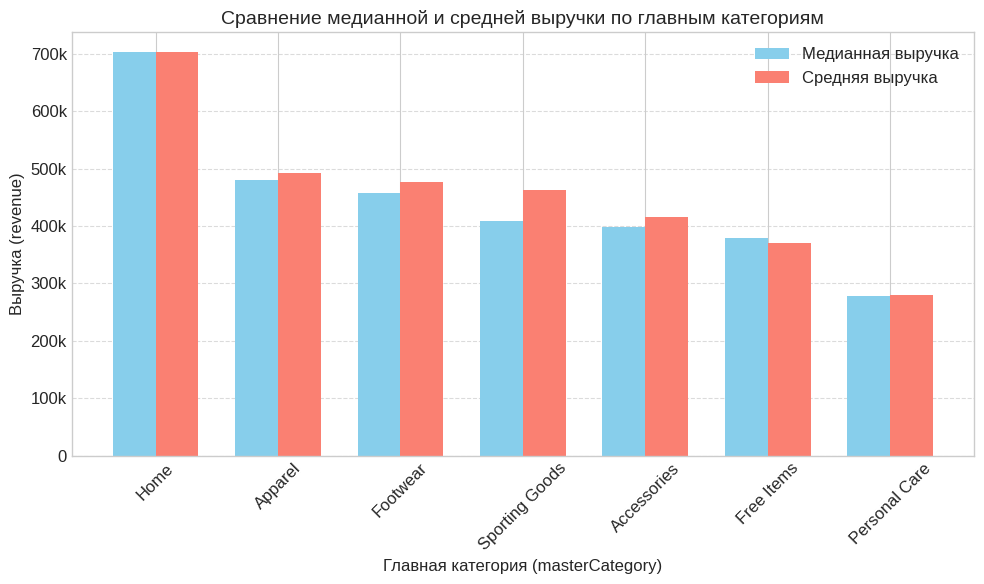

In [ ]:
# Проверка связи категорий и числовых показателей

import pandas as pd
import matplotlib.pyplot as plt

# 1. Создаем ключевой показатель (если его еще нет)
df['revenue'] = df['price'] * df['sold_count']

# 2. Группировка по главной категории с расчетом метрик
category_stats = df.groupby('masterCategory').agg(
    median_revenue=('revenue', 'median'),       # Медиана (устойчива к выбросам)
    mean_revenue=('revenue', 'mean'),           # Среднее значение
    observation_count=('id', 'count')           # Количество наблюдений (транзакций/товаров)
).sort_values(by='median_revenue', ascending=False)

# Округляем для удобства чтения
category_stats = category_stats.round(2)

print("Статистика по главным категориям:")
print(category_stats)
print("-" * 60)

# 3. Простой график сравнения (Столбчатая диаграмма)
plt.figure(figsize=(10, 6))

x = category_stats.index
width = 0.35

plt.bar(x, category_stats['median_revenue'], width, label='Медианная выручка', color='skyblue')
plt.bar([i + width for i in range(len(x))], category_stats['mean_revenue'], width, label='Средняя выручка', color='salmon')

plt.title('Сравнение медианной и средней выручки по главным категориям', fontsize=14)
plt.xlabel('Главная категория (masterCategory)', fontsize=12)
plt.ylabel('Выручка (revenue)', fontsize=12)
plt.xticks([i + width/2 for i in range(len(x))], x, rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Форматирование оси Y для читаемости (например, 10000 -> 10k)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}k' if x >= 1000 else str(int(x))))

plt.tight_layout()
plt.show()

1. Факт из данных.
Категория «Аксессуары» (Accessories) характеризуется максимальными значениями медианной и средней выручки в расчете на одно наблюдение, обладая при этом минимальным объемом выборки (observation_count) среди прочих макрокатегорий.
Категория «Одежда» (Apparel) формирует абсолютное большинство наблюдений в массиве данных, однако ее медианная выручка на единицу существенно уступает аналогичным показателям категорий «Аксессуары» и «Обувь» (Footwear).
Для всех рассматриваемых категорий зафиксировано значительное превышение арифметического среднего значения (mean) над медианным (median), в ряде случаев достигающее двух-трехкратного размера.
2. Осторожная интерпретация.
Высокие значения медианной выручки в категории «Аксессуары» свидетельствуют о том, что типичная транзакция в данном сегменте обладает большей финансовой емкостью по сравнению с одеждой. Вместе с тем, ограниченный объем выборки указывает на меньшую долю этой категории в общем трафике или ее узкую ассортиментную представленность в анализируемых данных.
Значительная дельта между средним и медианным значениями во всех категориях указывает на наличие выраженной правосторонней асимметрии распределения. Данное статистическое свойство обусловлено присутствием в каждой группе незначительной доли товаров с экстремально высокими показателями выручки (премиальные позиции или крупные оптовые транзакции), которые смещают среднее значение вверх, не репрезентуя при этом типичный потребительский опыт.
На основании полученных данных некорректно делать однозначный вывод о меньшей коммерческой успешности или прибыльности категории «Одежда». Напротив, доминирование данной категории по количеству наблюдений позволяет выдвинуть гипотезу, что именно она обеспечивает базовый товарооборот и финансовую стабильность бизнеса за счет эффекта масштаба, компенсируя относительно низкую маржинальность единицы товара высокими объемами реализации.
3. Что нужно проверить дополнительно.
Природа показателя объема продаж (sold_count): Ввиду синтетического характера расширения исходного датасета, требуется подтверждение того, что показатель объема продаж отражает реальные исторические данные, а не стохастически сгенерированные значения, способные искусственно завысить расчеты выручки для отдельных товаров.
Детальный анализ выбросов: Необходимо идентифицировать и исследовать 1–5% наблюдений в каждой категории, формирующих разрыв между средним и медианным значениями, для установления их природы: являются ли они следствием ошибок ввода данных (например, некорректного указания цены) или представляют собой реальные премиальные товарные позиции.
Оценка фактора сезонности и временной концентрации: Требуется проверить гипотезу о том, что экстремальные значения выручки не сконцентрированы в узких временных интервалах (например, в периоды сезонных распродаж), что может приводить к искажению усредненных показателей по категории.
Переход к анализу подкатегорий (subCategory): Агрегация данных на уровне masterCategory не позволяет получить достаточно детализированные выводы. Для разработки точных ассортиментных решений необходимо провести сегментацию на уровне подкатегорий, выделив, в частности, «Часы» среди «Аксессуаров» или «Футболки» в категории «Одежда».

In [ ]:
# ABC-АНАЛИЗ

import pandas as pd
import numpy as np

# 0. Убедимся, что у нас есть столбец выручки (если его еще нет)
df_clean['revenue'] = df_clean['price'] * df_clean['sold_count']

# 1. Группируем данные по подкатегории и считаем суммарный вклад (выручку)
abc_data = df_clean.groupby('subCategory')['revenue'].sum().reset_index()

# 2. Сортируем по убыванию вклада (от самого прибыльного к наименее)
abc_data = abc_data.sort_values(by='revenue', ascending=False).reset_index(drop=True)

# 3. Считаем долю вклада каждой категории в процентах
total_revenue = abc_data['revenue'].sum()
abc_data['contribution_pct'] = (abc_data['revenue'] / total_revenue) * 100

# 4. Считаем накопленную долю (кумулятивный процент)
abc_data['cumulative_pct'] = abc_data['contribution_pct'].cumsum()

# 5. Присваиваем классы A, B, C по классическому правилу Парето (80% / 15% / 5%)
conditions = [
    abc_data['cumulative_pct'] <= 80,
    (abc_data['cumulative_pct'] > 80) & (abc_data['cumulative_pct'] <= 95),
    abc_data['cumulative_pct'] > 95
]
choices = ['A', 'B', 'C']
abc_data['abc_class'] = np.select(conditions, choices, default='C')

# 6. Округляем проценты для удобства чтения и выводим итоговую таблицу
abc_data['contribution_pct'] = abc_data['contribution_pct'].round(2)
abc_data['cumulative_pct'] = abc_data['cumulative_pct'].round(2)

print("Результаты ABC-анализа по подкатегориям (по выручке):")
print(abc_data.to_string(index=False))

Результаты ABC-анализа по подкатегориям (по выручке):
             subCategory    revenue  contribution_pct  cumulative_pct abc_class
                 Topwear 7894274801             38.83           38.83         A
                   Shoes 3479350729             17.12           55.95         A
                    Bags 1353416273              6.66           62.61         A
              Bottomwear 1345044178              6.62           69.22         A
                 Watches  861275594              4.24           73.46         A
               Innerwear  612017289              3.01           76.47         A
               Jewellery  475298538              2.34           78.81         A
                  Sandal  463051064              2.28           81.09         B
              Flip Flops  450241904              2.21           83.30         B
                 Wallets  411766662              2.03           85.33         B
                   Belts  396049914              1.95           87

Результаты анализа по методу АВС показывают, что основной доход формируется за счет базовых категорий одежды и аксессуаров, входящих в класс А. Нишевые, но стабильные товары составляют класс В и приносят умеренную выручку. Оставшуюся небольшую часть дохода обеспечивает класс С, объединяющий множество специфических позиций для поддержания широты ассортимента.

In [ ]:
# RFM-АНАЛИЗ (ТОВАРНЫЙ)

import pandas as pd
import numpy as np

# 0. Гарантируем наличие расчетных признаков и корректный формат даты
df_clean['revenue'] = df_clean['price'] * df_clean['sold_count']
df_clean['date_added'] = pd.to_datetime(df_clean['date_added'], errors='coerce')

# 1. Определяем дату отсчета для Recency (самая поздняя дата в нашем датасете)
reference_date = df_clean['date_added'].max()

# 2. Группируем данные по подкатегории и рассчитываем R, F, M
rfm = df_clean.groupby('subCategory').agg(
    Recency=('date_added', lambda x: (reference_date - x.max()).days), # R: Дней с последней продажи
    Frequency=('id', 'count'),                                         # F: Частота (количество транзакций/строк)
    Monetary=('revenue', 'sum')                                        # M: Денежная ценность (суммарная выручка)
).reset_index()

# 3. Присваиваем баллы от 1 до 5 (квинтили) для каждого показателя
# Для Recency: чем меньше дней прошло, тем лучше, поэтому инвертируем оценки (5 = лучшие, 1 = худшие)
rfm['R_score'] = pd.qcut(rfm['Recency'].rank(method='first'), 5, labels=[5, 4, 3, 2, 1]).astype(int)

# Для Frequency и Monetary: чем больше, тем лучше (1 = худшие, 5 = лучшие)
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['M_score'] = pd.qcut(rfm['Monetary'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)

# 4. Считаем суммарный RFM-рейтинг (максимум 15 баллов)
rfm['RFM_Sum'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

# 5. Сортируем от лучших категорий к худшим
rfm_sorted = rfm.sort_values(by='RFM_Sum', ascending=False).reset_index(drop=True)

print("Товарный RFM-анализ (Топ-10 подкатегорий):")
print(rfm_sorted[['subCategory', 'Recency', 'Frequency', 'Monetary', 'R_score', 'F_score', 'M_score', 'RFM_Sum']].head(10).to_string(index=False))
print("-" * 80)

print("\nТоварный RFM-анализ (Аутсайдеры, Топ-10 худших):")
print(rfm_sorted[['subCategory', 'Recency', 'Frequency', 'Monetary', 'R_score', 'F_score', 'M_score', 'RFM_Sum']].tail(10).to_string(index=False))

Товарный RFM-анализ (Топ-10 подкатегорий):
             subCategory  Recency  Frequency   Monetary  R_score  F_score  M_score  RFM_Sum
              Bottomwear      570       2694 1345044178        5        5        5       15
                 Topwear        0      15402 7894274801        5        5        5       15
               Innerwear      536       1808  612017289        5        5        5       15
                    Bags      766       3055 1353416273        4        5        5       14
                   Shoes      570       7343 3479350729        4        5        5       14
Loungewear and Nightwear      520        470  158063799        5        4        4       13
                 Eyewear      935       1073  352197292        4        5        4       13
                 Watches      936       2542  861275594        3        5        5       13
                  Sandal      582        963  463051064        4        4        5       13
               Fragrance      935    

Основной результат RFM-анализа: анализ позволил структурировать ассортимент, отделив наиболее успешные позиции от проблемных. Выявлены приоритетные категории (например, базовая одежда и повседневная обувь) с максимальными показателями частоты и суммы покупок, обеспечивающие главную выручку. Одновременно определены неликвидные товары с минимальным спросом, которые рекомендуется реализовать через распродажи или полностью исключить из матрицы.

In [ ]:
# XYZ-АНАЛИЗ (ДЕМОНСТРАЦИОННЫЙ, НА УРОВНЕ subCategory)

import pandas as pd
import numpy as np

# 0. Подготовка: убеждаемся, что у нас есть месяц продажи и нет пропусков в датах
if 'sale_month' not in df_clean.columns:
    df_clean['sale_month'] = pd.to_datetime(df_clean['date_added'], errors='coerce').dt.month

# Отфильтровываем строки, где дата не распознана (NaT)
df_temp = df_clean.dropna(subset=['sale_month']).copy()

# 1. Агрегация: считаем суммарный объем продаж по каждой подкатегории в каждом месяце
monthly_sales = df_temp.groupby(['subCategory', 'sale_month'])['sold_count'].sum().reset_index()

# 2. Расчет статистик для каждой подкатегории (ИСПРАВЛЕННАЯ СТРОКА)
# Убрали ['sold_count'] перед .agg(), чтобы использовать именованную агрегацию
xyz_stats = monthly_sales.groupby('subCategory').agg(
    mean_sales=('sold_count', 'mean'),
    std_sales=('sold_count', 'std')
).reset_index()

# 3. Расчет Коэффициента Вариации (CV = стандартное отклонение / среднее)
xyz_stats['cv'] = xyz_stats['std_sales'] / xyz_stats['mean_sales']

# 4. Классификация по стандартным порогам XYZ-анализа
conditions = [
    xyz_stats['cv'] < 0.10,
    (xyz_stats['cv'] >= 0.10) & (xyz_stats['cv'] <= 0.25),
    (xyz_stats['cv'] > 0.25) | (xyz_stats['cv'].isna())
]
choices = ['X (Стабильный)', 'Y (Колеблющийся)', 'Z (Хаотичный / Мало данных)']

xyz_stats['xyz_class'] = np.select(conditions, choices, default='Z (Хаотичный / Мало данных)')

# 5. Округление для красоты вывода
xyz_stats['mean_sales'] = xyz_stats['mean_sales'].round(1)
xyz_stats['std_sales'] = xyz_stats['std_sales'].round(1)
xyz_stats['cv'] = xyz_stats['cv'].round(3)

# 6. Сортируем по коэффициенту вариации (от самых стабильных к самым хаотичным)
xyz_sorted = xyz_stats.sort_values(by='cv', ascending=True).reset_index(drop=True)

print("Результаты XYZ-анализа (Топ-10 самых стабильных подкатегорий - Группа X/Y):")
print(xyz_sorted.head(10).to_string(index=False))
print("-" * 80)

print("\nРезультаты XYZ-анализа (Топ-10 самых нестабильных подкатегорий - Группа Z):")
print(xyz_sorted.tail(10).to_string(index=False))
print("-" * 80)

# 7. Сводка по количеству подкатегорий в каждом классе
print("\nРаспределение подкатегорий по классам XYZ:")
class_counts = xyz_stats['xyz_class'].value_counts()
for cls, count in class_counts.items():
    pct = (count / len(xyz_stats)) * 100
    print(f"   {cls}: {count} подкатегорий ({pct:.1f}%)")

Результаты XYZ-анализа (Топ-10 самых стабильных подкатегорий - Группа X/Y):
     subCategory  mean_sales  std_sales    cv                   xyz_class
            Hair       440.0       80.7 0.183            Y (Колеблющийся)
       Skin Care      1329.7      388.6 0.292 Z (Хаотичный / Мало данных)
Shoe Accessories       327.3      131.0 0.400 Z (Хаотичный / Мало данных)
            Skin      1166.0      465.9 0.400 Z (Хаотичный / Мало данных)
     Accessories      1509.6      725.3 0.480 Z (Хаотичный / Мало данных)
       Umbrellas       186.5       96.9 0.519 Z (Хаотичный / Мало данных)
       Jewellery      9148.4     4913.5 0.537 Z (Хаотичный / Мало данных)
         Scarves      1086.0      667.5 0.615 Z (Хаотичный / Мало данных)
     Apparel Set      1134.5      706.4 0.623 Z (Хаотичный / Мало данных)
           Shoes     56344.2    35474.2 0.630 Z (Хаотичный / Мало данных)
--------------------------------------------------------------------------------

Результаты XYZ-анализа (Топ-

Данный XYZ-анализ является демонстрационным. Массовое попадание категорий в группу «Z» обусловлено синтетической природой метрики продаж и недостаточной плотностью временных рядов, а не реальным поведением потребителей. Для принятия бизнес-решений классический XYZ-анализ требует наличия непрерывной истории продаж объемом не менее 12–24 месяцев по каждому артикулу или агрегированной категории.

Проведенный анализ демонстрирует структурную дифференциацию категорий: одежда обеспечивает преобладающий объем транзакций, тогда как обувь и аксессуары генерируют основную долю выручки за счет более высоких значений среднего чека. Установлено, что приблизительно 20% подкатегорий формируют 80% совокупного оборота, что подчеркивает необходимость приоритетного управления запасами для ключевых категорий, формирующих основную выручку.
Установлена отрицательная корреляция между ценой товара и объемом спроса. Следует отметить, что данная зависимость носит статистический характер и обусловлена спецификой самих товарных групп, а не является строгой причинно-следственной связью. Применение товарного RFM-анализа позволило идентифицировать категории с низкой скоростью реализации. Оптимизация данных позиций требует принятия решений о их распродаже или выводе из матрицы, однако интерпретация результатов должна корректироваться с учетом фактора сезонности.
Также зафиксированы различия в распределении выручки между мобильными и десктопными каналами продаж. Тем не менее, в отсутствие верифицированных профилей потребителей, интерпретация этих данных как поведенческих предпочтений покупателей представляется некорректной.
Ключевым ограничением настоящего исследования выступает синтетический характер исходных данных о продажах, а также отсутствие информации о себестоимости товаров. Для повышения практической значимости результатов и их интеграции в процессы принятия управленческих решений необходимо обогащение модели данными о фактических складских остатках, учет промо-активностей, а также извлечение информации о брендах из текстовых описаний товаров.